In [ ]:
import pandas as pd

def cargar_datos(archivo):
    with open(archivo, 'r') as f:
        lineas = f.readlines()
    idx = [i for i, l in enumerate(lineas) if 'endheader' in l][0] + 1
    return pd.read_csv(archivo, sep='\t', skiprows=idx)

# 1. Cargamos ángulos y posiciones
df_ang = cargar_datos('degrees_arm26_elbow70+finger.mot')
df_pos = cargar_datos('arm26_BodyKinematics_pos_global.sto')

# 2. Seleccionamos lo importante
# Ángulos articulares
cols_articulares = ['time', '/jointset/r_shoulder/r_shoulder_elev/value', '/jointset/r_elbow/r_elbow_flex/value']
# Posiciones de los segmentos (Marcadores globales)
cols_cartesianas = ['time', 'base_X', 'base_Y', 'base_Z', 'r_humerus_X', 'r_humerus_Y', 'r_humerus_Z', 'r_ulna_radius_hand_X', 'r_ulna_radius_hand_Y', 'r_ulna_radius_hand_Z']

# 3. Unimos las tablas
df_completo = pd.merge(df_ang[cols_articulares], df_pos[cols_cartesianas], on='time')

# 4. Cambiamos nombres para que el tutor lo entienda a la primera
nombres = {
    '/jointset/r_shoulder/r_shoulder_elev/value': 'ang_hombro',
    '/jointset/r_elbow/r_elbow_flex/value': 'ang_codo',
    'r_humerus_X': 'brazo_X', 'r_humerus_Y': 'brazo_Y', 'r_humerus_Z': 'brazo_Z',
    'r_ulna_radius_hand_X': 'mano_X', 'r_ulna_radius_hand_Y': 'mano_Y', 'r_ulna_radius_hand_Z': 'mano_Z'
}
df_completo.rename(columns=nombres, inplace=True)

# 5. Guardar el resultado final
df_completo.to_csv('dataset_completo_marcadores.csv', index=False)
print("¡Dataset completo guardado!")

¡Dataset completo guardado!


In [ ]:
import pandas as pd

def cargar_datos_opensim(archivo):
    with open(archivo, 'r') as f:
        lineas = f.readlines()
    for i, linea in enumerate(lineas):
        if 'endheader' in linea:
            # Leemos el archivo y limpiamos espacios vacíos en los nombres de las columnas
            df = pd.read_csv(archivo, sep='\t', skiprows=i+1)
            df.columns = df.columns.str.strip()
            return df

# 1. CARGAR LOS ARCHIVOS COMPLETOS
df_ang = cargar_datos_opensim('degrees_arm26_elbow70+finger.mot')
df_pos = cargar_datos_opensim('arm26_BodyKinematics_pos_global.sto')

# 2. UNIR AUTOMÁTICAMENTE LOS DATAFRAMES POR LA COLUMNA 'time'
dataset_completo = pd.merge(df_ang, df_pos, on='time')

# 3. GUARDAR EL RESULTADO
dataset_completo.to_csv('dataset_completo_tfm.csv', index=False)

print(f"¡Hecho! Se han incluido {len(dataset_completo.columns)} columnas automáticamente.")

¡Hecho! Se han incluido 38 columnas automáticamente.
Columnas incluidas: ['time', '/jointset/r_shoulder/r_shoulder_elev/value', '/jointset/r_shoulder/r_shoulder_elev/speed', '/jointset/r_elbow/r_elbow_flex/value', '/jointset/r_elbow/r_elbow_flex/speed', '/forceset/TRIlong/activation', '/forceset/TRIlong/fiber_length', '/forceset/TRIlat/activation', '/forceset/TRIlat/fiber_length', '/forceset/TRImed/activation', '/forceset/TRImed/fiber_length', '/forceset/BIClong/activation', '/forceset/BIClong/fiber_length', '/forceset/BICshort/activation', '/forceset/BICshort/fiber_length', '/forceset/BRA/activation', '/forceset/BRA/fiber_length', 'base_X', 'base_Y', 'base_Z', 'base_Ox', 'base_Oy', 'base_Oz', 'r_humerus_X', 'r_humerus_Y', 'r_humerus_Z', 'r_humerus_Ox', 'r_humerus_Oy', 'r_humerus_Oz', 'r_ulna_radius_hand_X', 'r_ulna_radius_hand_Y', 'r_ulna_radius_hand_Z', 'r_ulna_radius_hand_Ox', 'r_ulna_radius_hand_Oy', 'r_ulna_radius_hand_Oz', 'center_of_mass_X', 'center_of_mass_Y', 'center_of_mass_Z

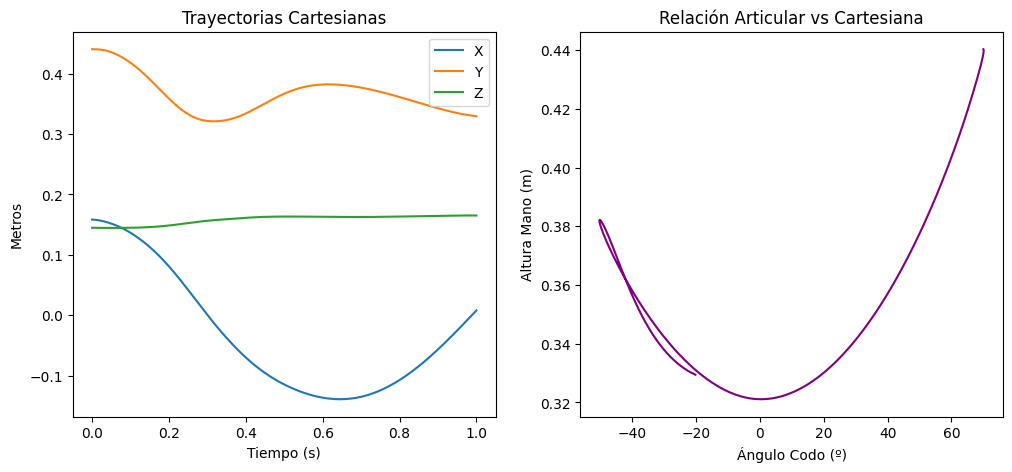

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Generar Visualizaciones
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df_completo['time'], df_completo['mano_X'], label='X'), plt.plot(df_completo['time'], df_completo['mano_Y'], label='Y'), plt.plot(df_completo['time'], df_completo['mano_Z'], label='Z')
plt.title('Trayectorias Cartesianas'); plt.xlabel('Tiempo (s)'); plt.ylabel('Metros'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df_completo['ang_codo'], df_completo['mano_Y'], color='purple')
plt.title('Relación Articular vs Cartesiana'); plt.xlabel('Ángulo Codo (º)'); plt.ylabel('Altura Mano (m)')
plt.show()

Error Medio: 673941323.2580 grados
Precisión (R2): 88.82%


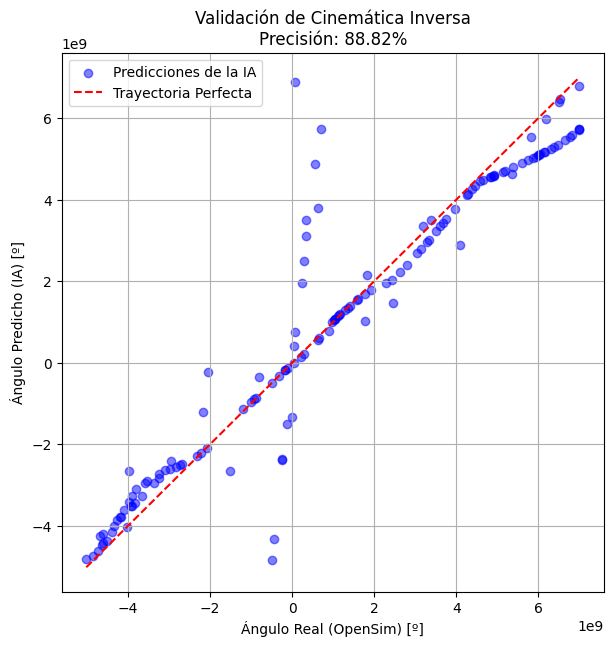

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# --- FUNCIÓN PARA LEER EL ARCHIVO SIN ERRORES ---
def leer_csv_robusto(nombre_archivo):
    # 'sep=None' con 'engine=python' detecta automáticamente si es coma, tabulador o espacio
    df = pd.read_csv(nombre_archivo, sep=None, engine='python')
    # Limpiamos los nombres de las columnas por si tienen espacios raros
    df.columns = df.columns.str.strip()
    return df

# 1. CARGAR LOS DATOS
df = leer_csv_robusto('dataset_completo_tfm.csv')

# 2. SELECCIONAR VARIABLES (Cinemática Inversa: Posición -> Ángulo)
# Usamos los nombres exactos que sacamos en el dataset completo
X = df[['r_ulna_radius_hand_X', 'r_ulna_radius_hand_Y', 'r_ulna_radius_hand_Z']].values
y = df[['/jointset/r_elbow/r_elbow_flex/value']].values

# 3. PREPARAR LOS DATOS (Escalado)
sc_X = StandardScaler()
sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 4. ENTRENAR LA IA
modelo = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=2000, random_state=42)
modelo.fit(X_train, y_train.ravel()) # .ravel() es para evitar un aviso de Python

# 5. EXAMEN (Validación)
y_pred_scaled = modelo.predict(X_test)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)) 
y_real = sc_y.inverse_transform(y_test)

# 6. MÉTRICAS PARA EL TUTOR
error_grados = mean_absolute_error(y_real, y_pred)
precision = r2_score(y_test, y_pred_scaled) * 100

print(f"Error Medio: {error_grados:.4f} grados")
print(f"Precisión (R2): {precision:.2f}%")

# 7. GRÁFICA
plt.figure(figsize=(7,7))
plt.scatter(y_real, y_pred, color='blue', alpha=0.5, label='Predicciones de la IA')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--', label='Trayectoria Perfecta')
plt.title(f'Validación de Cinemática Inversa\nPrecisión: {precision:.2f}%')
plt.xlabel('Ángulo Real (OpenSim) [º]')
plt.ylabel('Ángulo Predicho (IA) [º]')
plt.legend()
plt.grid(True)
plt.show()

Limpiando y cargando: Movimiento_1...
Limpiando y cargando: Movimiento_2...


Limpiando y cargando: Movimiento_3...
Limpiando y cargando: Movimiento_4...
Dataset listo: 2509 filas sin errores.
Precisión (R2): 99.68%
Error Medio: 1.42 grados


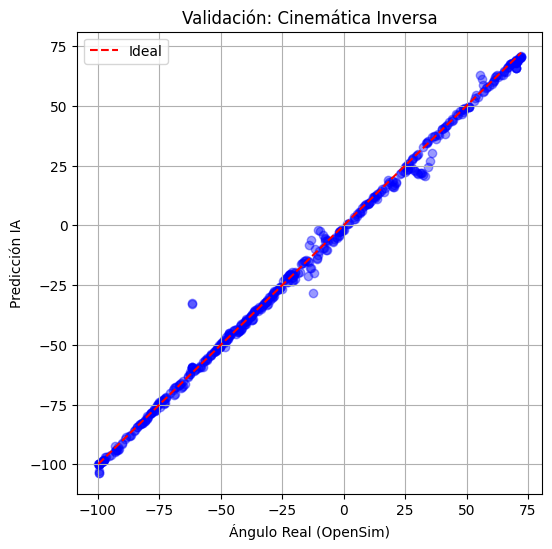

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ELIMINAR NA
def cargar_y_limpiar_total(ruta):
    with open(ruta, 'r') as f:
        lineas = f.readlines()
    skip = [i for i, l in enumerate(lineas) if 'endheader' in l][0] + 1
    
    # Leemos el archivo
    df = pd.read_csv(ruta, sep='\t', skiprows=skip)
    df.columns = df.columns.str.strip()
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Ahora sí, borramos todas las filas que tengan algún NaN
    df_limpio = df.dropna()
    return df_limpio

# PROCESAR CARPETAS
carpetas = ['Movimiento_1', 'Movimiento_2', 'Movimiento_3', 'Movimiento_4']
lista_df = []

for c in carpetas:
    if os.path.exists(c):
        print(f"Limpiando y cargando: {c}...")
        # Busca cualquier archivo .mot y .sto dentro
        file_mot = glob.glob(os.path.join(c, "*.mot"))[0]
        file_sto = glob.glob(os.path.join(c, "*.sto"))[0]
        
        df_a = cargar_y_limpiar_total(file_mot)
        df_p = cargar_y_limpiar_total(file_sto)
        
        unido = pd.merge(df_a, df_p, on='time')
        lista_df.append(unido)

# UNIMOS TODO 
df_total = pd.concat(lista_df, ignore_index=True)
print(f"Dataset listo: {len(df_total)} filas sin errores.")

# ENTRENAMIENTO
X = df_total[['r_ulna_radius_hand_X', 'r_ulna_radius_hand_Y', 'r_ulna_radius_hand_Z']]
y = df_total[['/jointset/r_elbow/r_elbow_flex/value']]

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

ia = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=2000)
ia.fit(X_train, y_train.values.ravel())

# RESULTADOS
predicciones = ia.predict(X_test)
print(f"Precisión (R2): {r2_score(y_test, predicciones)*100:.2f}%")
print(f"Error Medio: {mean_absolute_error(y_test, predicciones):.2f} grados")

# Gráfica Final
plt.figure(figsize=(6,6))
plt.scatter(y_test, predicciones, alpha=0.4, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal')
plt.title("Validación: Cinemática Inversa")
plt.xlabel("Ángulo Real (OpenSim)"); plt.ylabel("Predicción IA")
plt.legend(); plt.grid(True)
plt.show()

In [6]:
import pandas as pd
import os

def cargar_datos_opensim(archivo):
    """Lee un archivo de OpenSim y lo convierte en DataFrame."""
    with open(archivo, 'r') as f:
        lineas = f.readlines()
    
    idx = [i for i, l in enumerate(lineas) if 'endheader' in l.strip()][0] + 1
    return pd.read_csv(archivo, sep='\t', skiprows=idx)

# 1. Definimos los nombres exactos de tus carpetas
carpetas = ['movimiento_1', 'movimiento_2', 'movimiento_3', 'movimiento_4']

# 2. Definimos los nombres ORIGINALES de los archivos dentro de cada carpeta
archivos_originales = {
    'angulos_y_musculos': 'angulos.mot',
    'posiciones': 'posiciones.sto',
    'velocidades': 'velocidades.sto',
    'aceleraciones': 'aceleraciones.sto'
}

todos_los_datasets = [] 

# 3. Bucle para entrar en cada carpeta y procesar sus datos
for carpeta in carpetas:
    print(f"--- Procesando {carpeta} ---")
    dataframes_movimiento = {}
    
    # Cargar los 4 archivos dentro de la carpeta actual
    for nombre_tipo, nombre_archivo in archivos_originales.items():
        # Construimos la ruta uniendo la carpeta y el archivo (Ej: movimiento_1/angulos.mot)
        ruta = os.path.join(carpeta, nombre_archivo)
        
        if os.path.exists(ruta):
            df = cargar_datos_opensim(ruta)
            
            # Sufijos a las columnas (excepto a 'time') para no mezclar variables
            if nombre_tipo != 'angulos_y_musculos':
                df = df.rename(columns={col: f"{col}_{nombre_tipo}" for col in df.columns if col != 'time'})
                
            dataframes_movimiento[nombre_tipo] = df
            print(f"  Cargado: {ruta}")
        else:
            print(f"  ⚠️ No se encontró: {ruta}")
            
    # Fusionar los datos de este movimiento usando el tiempo (Inner Join)
    df_movimiento = None
    for nombre_tipo, df in dataframes_movimiento.items():
        if df_movimiento is None:
            df_movimiento = df
        else:
            df_movimiento = pd.merge(df_movimiento, df, on='time', how='inner')
            
    # Añadimos una columna para que la IA sepa de qué carpeta viene cada fila
    if df_movimiento is not None and not df_movimiento.empty:
        df_movimiento['ID_Movimiento'] = carpeta
        todos_los_datasets.append(df_movimiento)

# 4. Apilar todos los movimientos uno debajo del otro
if todos_los_datasets:
    # Unimos todo en un único DataFrame gigante
    df_final_completo = pd.concat(todos_los_datasets, ignore_index=True)
    
    # Guardar el CSV definitivo en la carpeta principal
    df_final_completo.to_csv('dataset_4_movimientos_tfm.csv', index=False)
    
    print("\n" + "="*40)
    print("¡TODO UNIDO CON ÉXITO!")
    print(f"Filas totales (instantes de tiempo): {df_final_completo.shape[0]}")
    print(f"Columnas (variables físicas): {df_final_completo.shape[1]}")
    print("Dataset guardado en la carpeta raíz como: 'dataset_4_movimientos_tfm.csv'")
else:
    print("\nNo se ha podido procesar ningún movimiento. Comprueba que las carpetas estén junto al Notebook.")

--- Procesando movimiento_1 ---
  Cargado: movimiento_1\angulos.mot
  Cargado: movimiento_1\posiciones.sto
  Cargado: movimiento_1\velocidades.sto
  Cargado: movimiento_1\aceleraciones.sto
--- Procesando movimiento_2 ---
  Cargado: movimiento_2\angulos.mot
  Cargado: movimiento_2\posiciones.sto
  Cargado: movimiento_2\velocidades.sto
  Cargado: movimiento_2\aceleraciones.sto
--- Procesando movimiento_3 ---
  Cargado: movimiento_3\angulos.mot
  Cargado: movimiento_3\posiciones.sto
  Cargado: movimiento_3\velocidades.sto
  Cargado: movimiento_3\aceleraciones.sto
--- Procesando movimiento_4 ---
  Cargado: movimiento_4\angulos.mot
  Cargado: movimiento_4\posiciones.sto
  Cargado: movimiento_4\velocidades.sto
  Cargado: movimiento_4\aceleraciones.sto

¡TODO UNIDO CON ÉXITO!
Filas totales (instantes de tiempo): 3494
Columnas (variables físicas): 81
Dataset guardado en la carpeta raíz como: 'dataset_4_movimientos_tfm.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor # Asegúrate de tenerlo instalado: pip install xgboost

# ---------------------------------------------------------
# 1. CARGA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. CARGA, LIMPIEZA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
print("Cargando dataset...")
df = pd.read_csv('dataset_4_movimientos_tfm.csv')

print("Limpiando errores matemáticos de OpenSim...")
# 1.1 Convertir todas las columnas (excepto el texto ID_Movimiento) a números.
# 'errors=coerce' hace la magia: si encuentra un texto como '-nan(ind)', lo convierte en NaN real.
columnas_numericas = [col for col in df.columns if col != 'ID_Movimiento']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1.2 Eliminar las filas donde haya quedado algún NaN
filas_originales = len(df)
df = df.dropna()
filas_borradas = filas_originales - len(df)

print(f"✅ Limpieza completada: Se han eliminado {filas_borradas} filas defectuosas (-nan).")
print(f"Filas sanas restantes para entrenar: {len(df)}")

# 1.3 Identificar variables X e y
columnas_y = [col for col in df.columns if '/jointset/' in col]
columnas_x = [col for col in df.columns if col not in columnas_y 
              and col not in ['time', 'ID_Movimiento'] 
              and '/forceset/' not in col]

X = df[columnas_x]
y = df[columnas_y]

print(f"Entradas (X): {X.shape[1]} variables espaciales.")
print(f"Salidas a predecir (y): {y.shape[1]} variables articulares.")
# ---------------------------------------------------------
# 2. SEPARACIÓN Y ESCALADO
# ---------------------------------------------------------
# Separar en datos de entrenamiento (80%) y validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos (CRÍTICO para que MLP y RBF funcionen bien)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# ---------------------------------------------------------
# 3. DEFINICIÓN DE LOS 4 MODELOS
# ---------------------------------------------------------
# Nota: Como tenemos múltiples salidas (varias articulaciones a la vez), 
# algunos modelos como SVR necesitan un "envoltorio" llamado MultiOutputRegressor.

modelos = {
    "Regresion_Lineal": LinearRegression(),
    
    "MLP_Red_Neuronal": MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
    
    "RBF_SVR": MultiOutputRegressor(SVR(kernel='rbf', C=10, gamma='scale')),
    
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

# ---------------------------------------------------------
# 4. ENTRENAMIENTO Y EVALUACIÓN COMPETITIVA
# ---------------------------------------------------------
resultados = {}

print("\n" + "="*40)
print("INICIANDO ENTRENAMIENTO DE MODELOS")
print("="*40)

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    
    # Entrenar el modelo
    modelo.fit(X_train_scaled, y_train)
    
    # Hacer predicciones con los datos nunca vistos (X_test)
    predicciones = modelo.predict(X_test_scaled)
    
    # Calcular métricas globales (promedio de todas las articulaciones)
    r2 = r2_score(y_test, predicciones)
    mae = mean_absolute_error(y_test, predicciones)
    
    resultados[nombre] = {'R2': r2, 'MAE': mae}
    
    print(f"  -> Precisión (R2): {r2*100:.2f}%")
    print(f"  -> Error Medio Absoluto: {mae:.4f} (grados/velocidad)")
    print("-" * 40)

# ---------------------------------------------------------
# 5. RESUMEN FINAL
# ---------------------------------------------------------
print("\nRESUMEN DE LA COMPETICIÓN:")
mejor_modelo = max(resultados, key=lambda k: resultados[k]['R2'])
print(f"🏆 El mejor modelo para tu Cinemática Inversa es: {mejor_modelo}")

Cargando dataset...
Limpiando errores matemáticos de OpenSim...
✅ Limpieza completada: Se han eliminado 985 filas defectuosas (-nan).
Filas sanas restantes para entrenar: 2509
Entradas (X): 63 variables espaciales.
Salidas a predecir (y): 4 variables articulares.

INICIANDO ENTRENAMIENTO DE MODELOS
Entrenando Regresion_Lineal...
  -> Precisión (R2): 100.00%
  -> Error Medio Absoluto: 0.0008 (grados/velocidad)
----------------------------------------
Entrenando MLP_Red_Neuronal...
  -> Precisión (R2): 99.98%
  -> Error Medio Absoluto: 0.3426 (grados/velocidad)
----------------------------------------
Entrenando RBF_SVR...
  -> Precisión (R2): 99.96%
  -> Error Medio Absoluto: 1.5069 (grados/velocidad)
----------------------------------------
Entrenando XGBoost...
  -> Precisión (R2): 100.00%
  -> Error Medio Absoluto: 0.5361 (grados/velocidad)
----------------------------------------

RESUMEN DE LA COMPETICIÓN:
🏆 El mejor modelo para tu Cinemática Inversa es: Regresion_Lineal


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20844\1215898734.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres_modelos, y=r2_scores, ax=ax1, palette="viridis")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20844\1215898734.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres_modelos, y=mae_scores, ax=ax2, palette="magma")


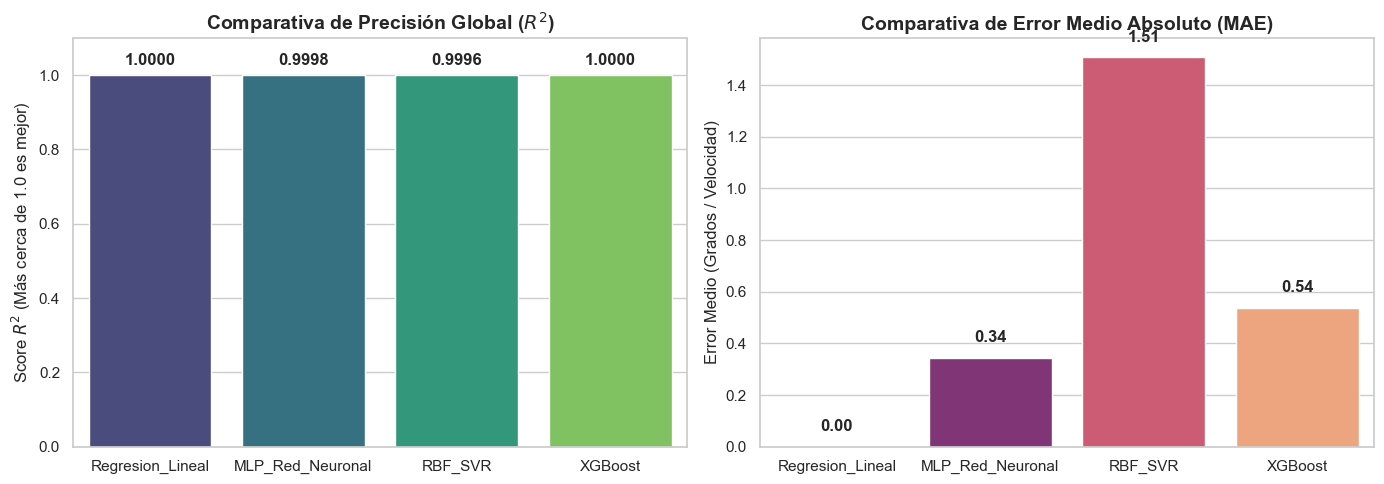

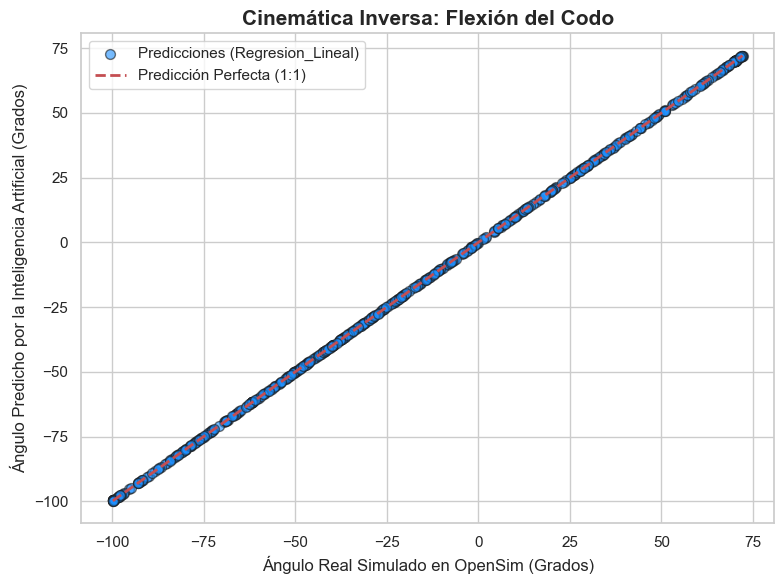

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo de las gráficas (más elegante para un TFM)
sns.set_theme(style="whitegrid")

# =====================================================================
# GRÁFICA 1: COMPARATIVA DE MODELOS (R2 y MAE)
# =====================================================================
# Extraemos los datos del diccionario 'resultados' que creamos antes
nombres_modelos = list(resultados.keys())
r2_scores = [resultados[n]['R2'] for n in nombres_modelos]
mae_scores = [resultados[n]['MAE'] for n in nombres_modelos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de R2 (Precisión)
sns.barplot(x=nombres_modelos, y=r2_scores, ax=ax1, palette="viridis")
ax1.set_title("Comparativa de Precisión Global ($R^2$)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Score $R^2$ (Más cerca de 1.0 es mejor)")
ax1.set_ylim(0, 1.1)
# Añadir el número encima de la barra
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Gráfico de MAE (Error)
sns.barplot(x=nombres_modelos, y=mae_scores, ax=ax2, palette="magma")
ax2.set_title("Comparativa de Error Medio Absoluto (MAE)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Error Medio (Grados / Velocidad)")
for i, v in enumerate(mae_scores):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# =====================================================================
# GRÁFICA 2: REALIDAD vs PREDICCIÓN (Flexión del Codo)
# =====================================================================
# 1. Identificamos cuál ha sido el mejor modelo
mejor_modelo_name = max(resultados, key=lambda k: resultados[k]['R2'])
mejor_modelo = modelos[mejor_modelo_name]

# 2. Hacemos las predicciones con los datos de test
predicciones_mejor = mejor_modelo.predict(X_test_scaled)

# 3. Buscamos qué columna corresponde a la flexión del codo
# (Cambiamos el nombre si tu columna se llama un poco diferente)
columna_codo = '/jointset/r_elbow/r_elbow_flex/value' 
if columna_codo in y.columns:
    idx_codo = list(y.columns).index(columna_codo)
    
    # Extraemos los ángulos reales y los predichos
    y_real_codo = y_test.iloc[:, idx_codo]
    y_pred_codo = predicciones_mejor[:, idx_codo]
    
    plt.figure(figsize=(8, 6))
    
    # Dibujamos los puntos
    plt.scatter(y_real_codo, y_pred_codo, alpha=0.6, color='dodgerblue', edgecolor='k', s=50, label=f'Predicciones ({mejor_modelo_name})')
    
    # Dibujamos la línea ideal (donde la predicción es 100% perfecta)
    min_val = min(y_real_codo.min(), y_pred_codo.min())
    max_val = max(y_real_codo.max(), y_pred_codo.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta (1:1)')
    
    plt.title("Cinemática Inversa: Flexión del Codo", fontsize=15, fontweight='bold')
    plt.xlabel("Ángulo Real Simulado en OpenSim (Grados)", fontsize=12)
    plt.ylabel("Ángulo Predicho por la Inteligencia Artificial (Grados)", fontsize=12)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontró la columna {columna_codo} para hacer la gráfica 2.")

In [15]:
print("Las variables que la IA va a intentar predecir (Matriz Y) son:")
for i, columna in enumerate(y.columns, 1):
    print(f"{i}. {columna}")

Las variables que la IA va a intentar predecir (Matriz Y) son:
1. /jointset/r_shoulder/r_shoulder_elev/value
2. /jointset/r_shoulder/r_shoulder_elev/speed
3. /jointset/r_elbow/r_elbow_flex/value
4. /jointset/r_elbow/r_elbow_flex/speed


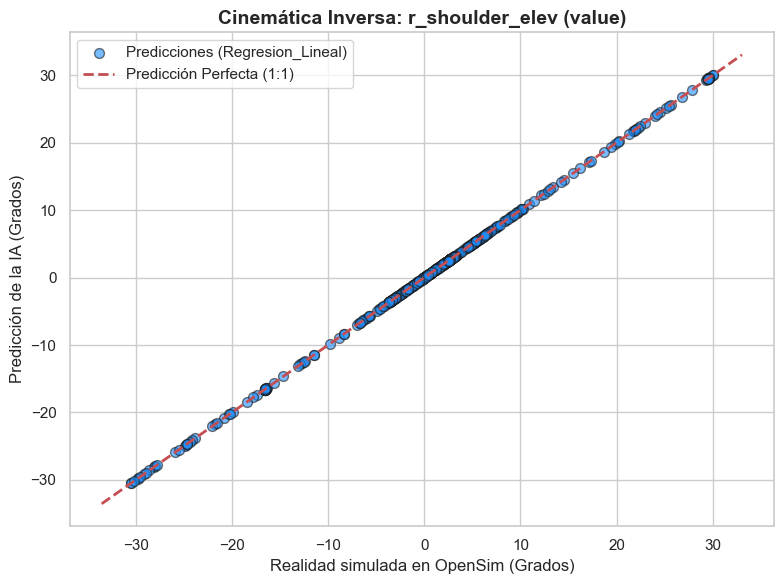

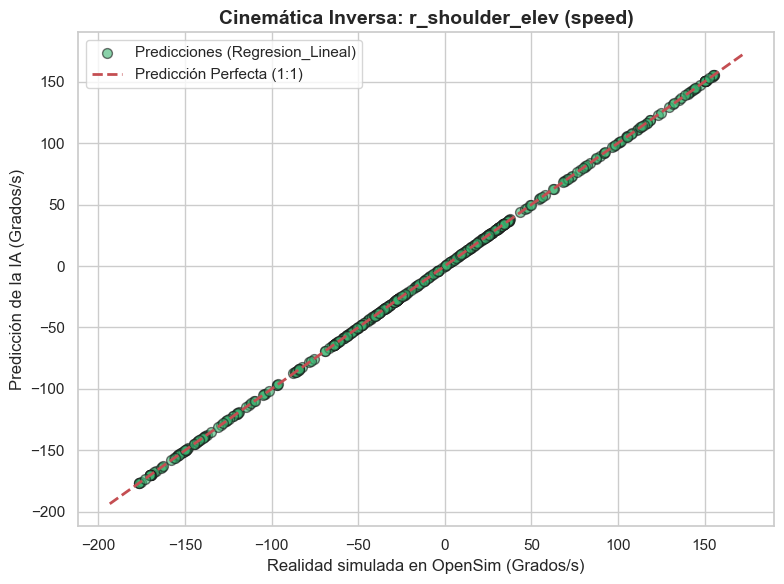

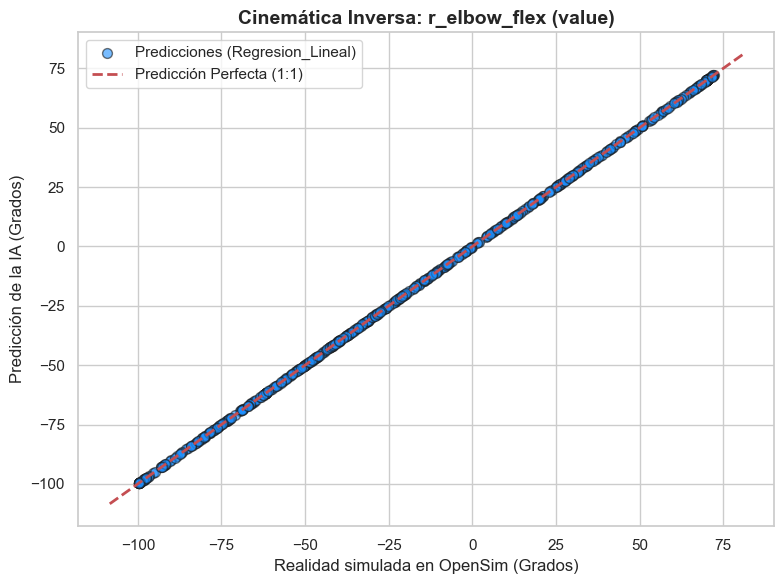

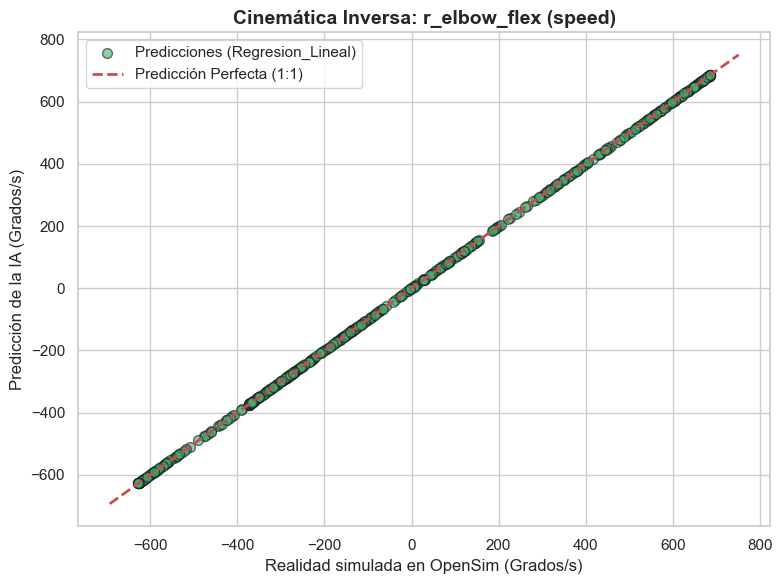

In [14]:
# =====================================================================
# GRÁFICAS AUTOMÁTICAS PARA TODAS LAS VARIABLES PREDICHAS
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Hacemos las predicciones con el mejor modelo
predicciones_mejor = mejor_modelo.predict(X_test_scaled)

# 2. Recorremos cada una de las columnas de nuestra variable 'y'
for i, columna in enumerate(y.columns):
    # Extraemos la realidad y la predicción para esta columna en concreto
    y_real = y_test.iloc[:, i]
    y_pred = predicciones_mejor[:, i]
    
    plt.figure(figsize=(8, 6))
    
    # Dibujamos los puntos (usamos un color distinto para los ángulos y las velocidades)
    color_puntos = 'dodgerblue' if 'value' in columna else 'mediumseagreen'
    plt.scatter(y_real, y_pred, alpha=0.6, color=color_puntos, edgecolor='k', s=50, 
                label=f'Predicciones ({mejor_modelo_name})')
    
    # Dibujamos la línea ideal (donde la predicción es 100% perfecta)
    min_val = min(y_real.min(), y_pred.min())
    max_val = max(y_real.max(), y_pred.max())
    
    # Añadimos un pequeño margen para visualizar mejor los puntos
    margen = (max_val - min_val) * 0.05
    if margen == 0: margen = 1 # Por si el brazo no se ha movido nada en esa articulación
    
    plt.plot([min_val - margen, max_val + margen], 
             [min_val - margen, max_val + margen], 'r--', lw=2, label='Predicción Perfecta (1:1)')
    
    # Damos formato al título para que sea legible en el TFM
    nombre_limpio = columna.split('/')[-2:] # Ej: ['r_elbow_flex', 'value']
    titulo = f"Cinemática Inversa: {nombre_limpio[0]} ({nombre_limpio[1]})"
    
    plt.title(titulo, fontsize=14, fontweight='bold')
    
    # Las etiquetas cambian si es una posición (grados) o una velocidad (grados/s)
    unidad = "Grados/s" if 'speed' in columna else "Grados"
    plt.xlabel(f"Realidad simulada en OpenSim ({unidad})", fontsize=12)
    plt.ylabel(f"Predicción de la IA ({unidad})", fontsize=12)
    
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

In [2]:
import pandas as pd
import os

def cargar_datos_opensim(archivo):
    """Lee cualquier archivo de OpenSim saltándose la cabecera."""
    with open(archivo, 'r') as f:
        lineas = f.readlines()
    idx = [i for i, l in enumerate(lineas) if 'endheader' in l.strip()][0] + 1
    return pd.read_csv(archivo, sep='\t', skiprows=idx)

# Definimos exactamente en qué carpeta están guardados los archivos
carpeta_datos = 'movimiento_1'

# 1. Todos tus archivos disponibles
archivos = {
    'cinematica': 'angulos.mot',
    'posiciones': 'posiciones.sto',
    'velocidades': 'velocidades.sto',
    'aceleraciones': 'aceleraciones.sto',
    'esfuerzo_muscular': 'fuerzas.sto',          # Del 0 al 1 (Activaciones)
    'fuerza_newtons': 'arm26_StaticOptimization_force.sto' # En Newtons
}

dataframes = {}

print("--- FUSIÓN MASIVA DE DATOS ---")
for nombre, archivo in archivos.items():
    # ¡NUEVO! Construimos la ruta exacta: "movimiento_1/archivo.sto"
    ruta = os.path.join(carpeta_datos, archivo)
    
    if os.path.exists(ruta):
        df = cargar_datos_opensim(ruta)
        
        # Añadir sufijos a las columnas (excepto el tiempo) para saber de dónde vienen
        if nombre != 'cinematica':
            df = df.rename(columns={col: f"{col}_{nombre}" for col in df.columns if col != 'time'})
            
        dataframes[nombre] = df
        print(f"✅ Cargado: {ruta} ({df.shape[1]} columnas)")
    else:
        print(f"⚠️ No encontrado: {ruta}")

# 2. Unir todo usando la columna 'time' (Milisegundo a milisegundo)
df_final = None
for nombre, df in dataframes.items():
    if df_final is None:
        df_final = df
    else:
        df_final = pd.merge(df_final, df, on='time', how='inner')

# 3. Limpieza de errores matemáticos de OpenSim (los -nan)
columnas = df_final.columns
for col in columnas:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final = df_final.dropna()

# 4. Guardar el Mega-Dataset en la misma carpeta que el Notebook
archivo_salida = 'MEGA_DATASET_TFM.csv'
df_final.to_csv(archivo_salida, index=False)

print("\n" + "="*40)
print("¡MEGA DATASET CREADO CON ÉXITO!")
print(f"Filas limpias (Instantes de tiempo): {df_final.shape[0]}")
print(f"Variables totales (Columnas): {df_final.shape[1]}")
print(f"Guardado como: {archivo_salida}")

--- FUSIÓN MASIVA DE DATOS ---
✅ Cargado: movimiento_1\angulos.mot (17 columnas)
✅ Cargado: movimiento_1\posiciones.sto (22 columnas)
✅ Cargado: movimiento_1\velocidades.sto (22 columnas)
✅ Cargado: movimiento_1\aceleraciones.sto (22 columnas)
✅ Cargado: movimiento_1\fuerzas.sto (13 columnas)
⚠️ No encontrado: movimiento_1\arm26_StaticOptimization_force.sto

¡MEGA DATASET CREADO CON ÉXITO!
Filas limpias (Instantes de tiempo): 712
Variables totales (Columnas): 92
Guardado como: MEGA_DATASET_TFM.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("Cargando el MEGA DATASET...")
df = pd.read_csv('MEGA_DATASET_TFM.csv')

# ---------------------------------------------------------
# 1. DEFINIR QUÉ ES LA PISTA (X) Y QUÉ QUEREMOS ADIVINAR (y)
# ---------------------------------------------------------
# X (Nuestra entrada): Solo le diremos a la IA dónde está la mano y la fuerza que aguanta
columnas_x = [
    'r_ulna_radius_hand_X_posiciones', 
    'r_ulna_radius_hand_Y_posiciones', 
    'r_ulna_radius_hand_Z_posiciones',
    'r_ulna_radius_hand_externalforce_Fy_esfuerzo_muscular' # La pesa de -49N
]

# y (Nuestras salidas): Queremos que adivine ABSOLUTAMENTE TODO LO DEMÁS
# (Excluimos el tiempo y las propias columnas de entrada)
columnas_y = [col for col in df.columns if col not in columnas_x and col != 'time']

X = df[columnas_x]
y = df[columnas_y]

print(f"La IA recibirá {X.shape[1]} datos de entrada (Posición de la mano).")
print(f"Y tendrá que deducir simultáneamente {y.shape[1]} variables físicas y musculares.")

# ---------------------------------------------------------
# 2. PREPARACIÓN Y ESCALADO (VITAL PARA PREDECIR TANTAS COSAS)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos tanto la entrada como la salida (al mezclar Newtons, con grados y metros, la IA necesita que todo esté equilibrado)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# ---------------------------------------------------------
# 3. ENTRENAMIENTO DEL SÚPER-MODELO
# ---------------------------------------------------------
# Usaremos un Random Forest masivo porque es muy robusto para predecir 80 columnas a la vez
print("\nEntrenando Modelo Predictor Universal (Esto puede tardar unos segundos)...")
modelo_universal = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_universal.fit(X_train_scaled, y_train_scaled)

# ---------------------------------------------------------
# 4. EVALUACIÓN Y RESULTADOS
# ---------------------------------------------------------
predicciones_scaled = modelo_universal.predict(X_test_scaled)

# Des-escalamos para leer los resultados en sus unidades originales (Grados, Newtons, Metros...)
predicciones = scaler_y.inverse_transform(predicciones_scaled)

r2_global = r2_score(y_test, predicciones)
print(f"\n✅ ¡ENTRENAMIENTO COMPLETADO!")
print(f"🏆 Precisión Global del Modelo (R2): {r2_global*100:.2f}%")

# Vamos a ver qué tal adivinó 3 cosas completamente distintas:
idx_codo = list(y.columns).index('/jointset/r_elbow/r_elbow_flex/value')
idx_musculo = list(y.columns).index('BRA_esfuerzo_muscular')
idx_vel = list(y.columns).index('r_humerus_X_velocidades')

print("\n--- EJEMPLOS DE PRECISIÓN ESPECÍFICA ---")
print(f"Error prediciendo el ángulo del codo: {mean_absolute_error(y_test.iloc[:, idx_codo], predicciones[:, idx_codo]):.2f} grados")
print(f"Error prediciendo el músculo Braquial: {mean_absolute_error(y_test.iloc[:, idx_musculo], predicciones[:, idx_musculo]):.4f} (Activación 0-1)")
print(f"Error prediciendo velocidad del húmero: {mean_absolute_error(y_test.iloc[:, idx_vel], predicciones[:, idx_vel]):.4f} m/s")

Cargando el MEGA DATASET...
La IA recibirá 4 datos de entrada (Posición de la mano).
Y tendrá que deducir simultáneamente 87 variables físicas y musculares.

Entrenando Modelo Predictor Universal (Esto puede tardar unos segundos)...

✅ ¡ENTRENAMIENTO COMPLETADO!
🏆 Precisión Global del Modelo (R2): 98.35%

--- EJEMPLOS DE PRECISIÓN ESPECÍFICA ---
Error prediciendo el ángulo del codo: 0.11 grados
Error prediciendo el músculo Braquial: 4.5281 (Activación 0-1)
Error prediciendo velocidad del húmero: 0.0019 m/s


In [4]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. CREAMOS LA "PREGUNTA" PARA LA IA (Nuestra pista inicial)
# ==============================================================================
# Imaginamos que la cámara o el videojuego nos dice que la mano está en esta posición:
datos_entrada = {
    'r_ulna_radius_hand_X_posiciones': [0.30],  # 30 cm a la derecha
    'r_ulna_radius_hand_Y_posiciones': [0.50],  # 50 cm de altura
    'r_ulna_radius_hand_Z_posiciones': [0.10],  # 10 cm de profundidad
    'r_ulna_radius_hand_externalforce_Fy_esfuerzo_muscular': [-49.0] # Pesa de 5kg tirando hacia abajo
}

# Lo convertimos en una tabla (DataFrame) para que la IA lo entienda
nueva_pista = pd.DataFrame(datos_entrada)

# ESCALAMOS la pista (porque la IA se entrenó con datos escalados)
nueva_pista_escalada = scaler_X.transform(nueva_pista)

# ==============================================================================
# 2. LA IA HACE SU PREDICCIÓN INSTANTÁNEA (Adivina las 80 cosas)
# ==============================================================================
prediccion_escalada = modelo_universal.predict(nueva_pista_escalada)

# DES-ESCALAMOS la respuesta para poder leerla en Grados, Metros, etc.
prediccion_real = scaler_y.inverse_transform(prediccion_escalada)

# (Esto extrae la primera y única fila de resultados)
resultado = prediccion_real[0] 

# ==============================================================================
# 3. EXTRAEMOS LAS RESPUESTAS (TRADUCIENDO LA PREDICCIÓN)
# ==============================================================================
# Guardamos en una lista los nombres de todas las cosas que adivinaba
nombres_y = list(columnas_y)

print("🎯 PREDICCIÓN BIOMECÁNICA INSTANTÁNEA 🎯")
print(f"Pista dada -> Mano en X:0.3, Y:0.5, Z:0.1 con Carga: -49N\n")

# --- BLOQUE 1: ARTICULACIONES ---
print("⚙️ BLOQUE 1: ARTICULACIONES (Chasis)")
idx_codo = nombres_y.index('/jointset/r_elbow/r_elbow_flex/value')
idx_vel_hombro = nombres_y.index('/jointset/r_shoulder/r_shoulder_elev/speed')
print(f" - Ángulo del codo adivinado: {resultado[idx_codo]:.2f} grados")
print(f" - Velocidad rotación hombro: {resultado[idx_vel_hombro]:.2f} grados/s\n")

# --- BLOQUE 2: MÚSCULOS ---
print("💪 BLOQUE 2: MÚSCULOS (Motores)")
idx_braquial = nombres_y.index('BRA_esfuerzo_muscular')
idx_triceps = nombres_y.index('TRIlong_esfuerzo_muscular')
print(f" - Esfuerzo del músculo Braquial: {resultado[idx_braquial]*100:.1f} % de su capacidad máxima")
print(f" - Esfuerzo del Tríceps largo: {resultado[idx_triceps]*100:.1f} % de su capacidad máxima\n")

# --- BLOQUE 3: POSICIONES ESPACIALES ---
print("📍 BLOQUE 3: POSICIÓN DE LOS HUESOS (GPS)")
idx_centro_gravedad_y = nombres_y.index('center_of_mass_Y_posiciones')
idx_inclinacion_humero = nombres_y.index('r_humerus_Ox_posiciones')
print(f" - Altura exacta del Centro de Masa: {resultado[idx_centro_gravedad_y]:.3f} metros")
print(f" - Inclinación del hueso húmero (Eje X): {resultado[idx_inclinacion_humero]:.3f} radianes\n")

# --- BLOQUE 4: DINAMISMO ---
print("🚀 BLOQUE 4: VELOCIDADES Y ACELERACIONES")
idx_vel_humero = nombres_y.index('r_humerus_Y_velocidades')
idx_acc_humero = nombres_y.index('r_humerus_Z_aceleraciones')
print(f" - Velocidad de subida del húmero: {resultado[idx_vel_humero]:.3f} metros/segundo")
print(f" - Aceleración lateral del húmero: {resultado[idx_acc_humero]:.3f} m/s²")

🎯 PREDICCIÓN BIOMECÁNICA INSTANTÁNEA 🎯
Pista dada -> Mano en X:0.3, Y:0.5, Z:0.1 con Carga: -49N

⚙️ BLOQUE 1: ARTICULACIONES (Chasis)
 - Ángulo del codo adivinado: 70.00 grados
 - Velocidad rotación hombro: -2.30 grados/s

💪 BLOQUE 2: MÚSCULOS (Motores)
 - Esfuerzo del músculo Braquial: 70640.3 % de su capacidad máxima
 - Esfuerzo del Tríceps largo: 65406.3 % de su capacidad máxima

📍 BLOQUE 3: POSICIÓN DE LOS HUESOS (GPS)
 - Altura exacta del Centro de Masa: 0.535 metros
 - Inclinación del hueso húmero (Eje X): 0.000 radianes

🚀 BLOQUE 4: VELOCIDADES Y ACELERACIONES
 - Velocidad de subida del húmero: 0.000 metros/segundo
 - Aceleración lateral del húmero: -17.989 m/s²


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Cargando el MEGA DATASET...")
df = pd.read_csv('MEGA_DATASET_TFM.csv')

# 1. DEFINIR X (Pista) e y (Las 80 variables a adivinar)
columnas_x = [
    'r_ulna_radius_hand_X_posiciones', 
    'r_ulna_radius_hand_Y_posiciones', 
    'r_ulna_radius_hand_Z_posiciones',
    'r_ulna_radius_hand_externalforce_Fy_esfuerzo_muscular'
]
columnas_y = [col for col in df.columns if col not in columnas_x and col != 'time']

X = df[columnas_x]
y = df[columnas_y]

# Separamos en Entrenamiento (80%) y Validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# ==============================================================================
# FASE 1: ENTRENAMIENTO DE LOS MODELOS
# ==============================================================================
modelos = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Red Neuronal (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (Kernel RBF)": MultiOutputRegressor(SVR(kernel='rbf')) 
}

modelos_entrenados = {}

print("\n⚙️ FASE 1: ENTRENANDO MODELOS...")
for nombre, modelo in modelos.items():
    print(f"   -> Entrenando {nombre}...")
    modelo.fit(X_train_scaled, y_train_scaled)
    modelos_entrenados[nombre] = modelo # Guardamos el modelo ya entrenado

# ==============================================================================
# FASE 2: VALIDACIÓN (PREDICCIÓN) Y CÁLCULO DE MÉTRICAS
# ==============================================================================
print("\n🔍 FASE 2: VALIDANDO Y COMPARANDO MÉTRICAS...")

resultados_lista = []

for nombre, modelo in modelos_entrenados.items():
    # El modelo intenta adivinar usando solo los datos de validación (X_test)
    predicciones_scaled = modelo.predict(X_test_scaled)
    
    # Des-escalamos para que el error se mida en las unidades reales
    predicciones = scaler_y.inverse_transform(predicciones_scaled)
    
    # Calculamos las métricas globales para las 80 columnas
    r2 = r2_score(y_test, predicciones)
    mae = mean_absolute_error(y_test, predicciones)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    
    # Guardamos los resultados en una lista
    resultados_lista.append({
        "Modelo": nombre,
        "R² (Precisión Global)": f"{r2 * 100:.2f} %",
        "MAE (Error Medio)": f"{mae:.4f}",
        "RMSE (Error Grave)": f"{rmse:.4f}"
    })

# ==============================================================================
# FASE 3: TABLA COMPARATIVA FINAL
# ==============================================================================
# Convertimos la lista de resultados en una tabla de Pandas bonita
tabla_resultados = pd.DataFrame(resultados_lista)

# Ordenamos la tabla de mejor a peor modelo (basado en el porcentaje R2)
tabla_resultados = tabla_resultados.sort_values(by="R² (Precisión Global)", ascending=False).reset_index(drop=True)

print("\n🏆 TABLA DE RESULTADOS FINALES 🏆")
display(tabla_resultados) # 'display' dibuja una tabla formateada en Jupyter Notebook

Cargando el MEGA DATASET...

⚙️ FASE 1: ENTRENANDO MODELOS...
   -> Entrenando Random Forest...
   -> Entrenando Red Neuronal (MLP)...
   -> Entrenando XGBoost...
   -> Entrenando SVM (Kernel RBF)...

🔍 FASE 2: VALIDANDO Y COMPARANDO MÉTRICAS...

🏆 TABLA DE RESULTADOS FINALES 🏆


,Modelo,R² (Precisión Global),MAE (Error Medio),RMSE (Error Grave)
0,Random Forest,98.35 %,8.6932,89.2029
1,XGBoost,97.17 %,21.3200,204.6517
2,SVM (Kernel RBF),91.85 %,171.7475,1204.2108
3,Red Neuronal (MLP),-12239922870797412137158311936.00 %,118.4929,1042.5005
